In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/sample/compliance_data.csv")
print(df.shape)
df.head()

(1000, 6)


,days_since_sync,os_version_risk,failed_policy_count,app_install_failures,assigned_policy_count,is_non_compliant
0,8.5,1,2,1,14,1
1,1.8,0,2,3,13,0
2,10.8,0,4,0,3,1
3,11.7,0,2,0,15,0
4,0.0,0,2,0,3,0


In [2]:
df.describe().round(2)

,days_since_sync,os_version_risk,failed_policy_count,app_install_failures,assigned_policy_count,is_non_compliant
count,1000.00,1000.0,1000.00,1000.00,1000.00,1000.00
mean,7.05,0.7,1.94,0.96,11.13,0.33
std,4.57,0.8,1.40,0.98,4.95,0.47
min,0.00,0.0,0.00,0.00,3.00,0.00
25%,3.50,0.0,1.00,0.00,7.00,0.00
50%,7.00,0.0,2.00,1.00,11.00,0.00
75%,9.93,1.0,3.00,1.00,16.00,1.00
max,22.90,2.0,7.00,5.00,19.00,1.00


In [3]:
df.isnull().sum()

days_since_sync          0
os_version_risk          0
failed_policy_count      0
app_install_failures     0
assigned_policy_count    0
is_non_compliant         0
dtype: int64

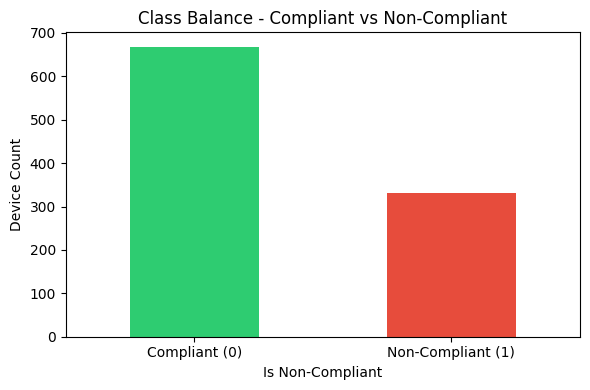

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
df['is_non_compliant'].value_counts().plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Class Balance - Compliant vs Non-Compliant')
ax.set_xlabel('Is Non-Compliant')
ax.set_ylabel('Device Count')
ax.set_xticklabels(['Compliant (0)', 'Non-Compliant (1)'], rotation=0)
plt.tight_layout()
plt.show()

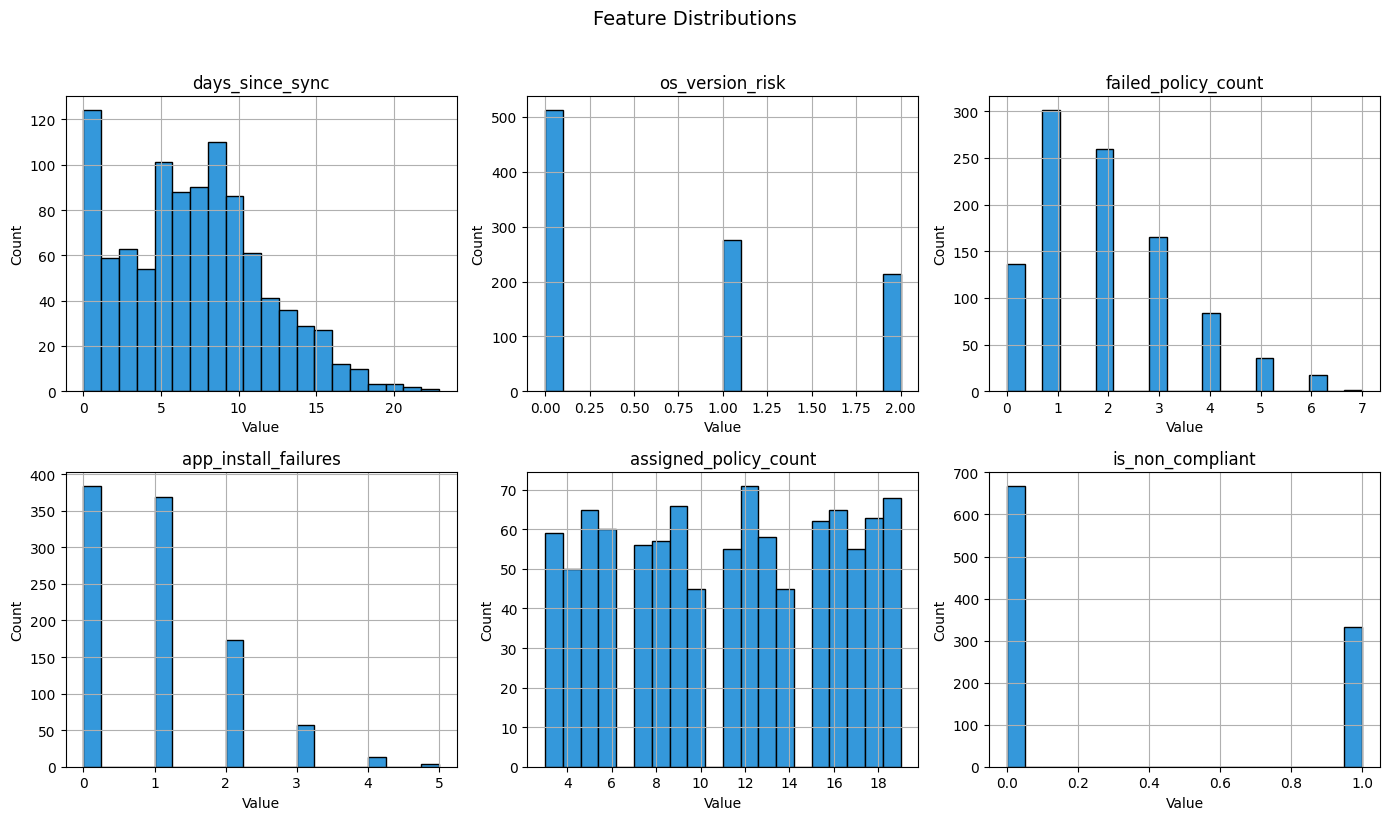

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

features = ['days_since_sync', 'os_version_risk', 'failed_policy_count',
            'app_install_failures', 'assigned_policy_count', 'is_non_compliant']

for i, feature in enumerate(features):
    df[feature].hist(ax=axes[i], bins=20, color='#3498db', edgecolor='black')
    axes[i].set_title(feature)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

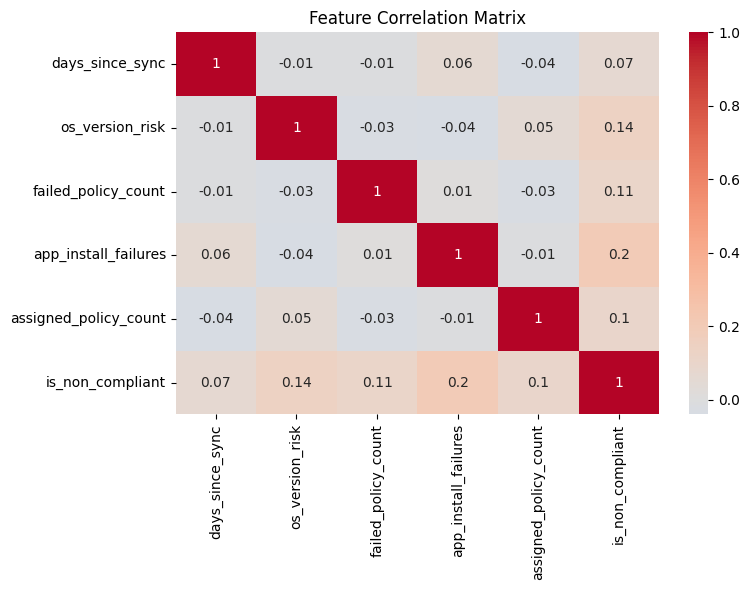

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df.corr().round(2), annot=True, cmap='coolwarm', 
            center=0, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()